In [1]:
# Imports the required Python libraries for data manipulation, visualization, and warning management.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import kagglehub

warnings.filterwarnings("ignore")

In [2]:
# Downloads the IPL dataset from Kaggle.

dataset_path = kagglehub.dataset_download(
    "patrickb1912/ipl-complete-dataset-20082020"
)

print("Dataset location:")
print(dataset_path)

Dataset location:
C:\Users\jclaz\.cache\kagglehub\datasets\patrickb1912\ipl-complete-dataset-20082020\versions\3


In [3]:
# Displays all files available in the downloaded dataset.

from pathlib import Path

dataset_files = [
    file.name
    for file in Path(dataset_path).rglob("*")
    if file.is_file()
]

dataset_files

['deliveries.csv', 'matches.csv']

In [4]:
# Finds the exact paths of the matches and deliveries CSV files.

matches_path = next(Path(dataset_path).rglob("matches.csv"))
deliveries_path = next(Path(dataset_path).rglob("deliveries.csv"))

print("Matches:", matches_path)
print("Deliveries:", deliveries_path)

Matches: C:\Users\jclaz\.cache\kagglehub\datasets\patrickb1912\ipl-complete-dataset-20082020\versions\3\matches.csv
Deliveries: C:\Users\jclaz\.cache\kagglehub\datasets\patrickb1912\ipl-complete-dataset-20082020\versions\3\deliveries.csv


In [5]:
# Loads both datasets into pandas DataFrames.

matches = pd.read_csv(matches_path)

deliveries = pd.read_csv(
    deliveries_path,
    encoding="latin1",
    engine="python",
    sep=None
)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [6]:
# Displays the first five rows of the matches dataset.

matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [7]:
# Displays the first five rows of the deliveries dataset.

deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [8]:
# Displays the number of rows and columns in each dataset.

print("Matches dataset shape:", matches.shape)
print("Deliveries dataset shape:", deliveries.shape)

Matches dataset shape: (1095, 20)
Deliveries dataset shape: (260920, 17)


In [9]:
# Displays general information about the matches dataset.

matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [10]:
# Displays general information about the deliveries dataset.

deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          260920 non-null  int64
 1   inning            260920 non-null  int64
 2   batting_team      260920 non-null  str  
 3   bowling_team      260920 non-null  str  
 4   over              260920 non-null  int64
 5   ball              260920 non-null  int64
 6   batter            260920 non-null  str  
 7   bowler            260920 non-null  str  
 8   non_striker       260920 non-null  str  
 9   batsman_runs      260920 non-null  int64
 10  extra_runs        260920 non-null  int64
 11  total_runs        260920 non-null  int64
 12  extras_type       14125 non-null   str  
 13  is_wicket         260920 non-null  int64
 14  player_dismissed  12950 non-null   str  
 15  dismissal_kind    12950 non-null   str  
 16  fielder           9354 non-null    str  
dtypes: int64(8), str(9)
m

In [11]:
# Displays all column names in both datasets.

print("Matches columns:")
print(matches.columns.tolist())

print("\nDeliveries columns:")
print(deliveries.columns.tolist())

Matches columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Deliveries columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [12]:
# Checks for missing values in the matches dataset.

matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [13]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [14]:
# Checks for duplicate rows in both datasets.

print("Duplicate rows in matches:", matches.duplicated().sum())
print("Duplicate rows in deliveries:", deliveries.duplicated().sum())

Duplicate rows in matches: 0
Duplicate rows in deliveries: 0


In [15]:
# Creates working copies of the original datasets.

matches_clean = matches.copy()
deliveries_clean = deliveries.copy()

print("Working copies created successfully.")

Working copies created successfully.


In [16]:
# Converts the date column into datetime format.

matches_clean["date"] = pd.to_datetime(matches_clean["date"])

print("Date column type:", matches_clean["date"].dtype)

Date column type: datetime64[us]


In [17]:
# Standardizes team names that changed across IPL seasons.

team_name_mapping = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
}

matches_clean["team1"] = matches_clean["team1"].replace(team_name_mapping)
matches_clean["team2"] = matches_clean["team2"].replace(team_name_mapping)
matches_clean["toss_winner"] = matches_clean["toss_winner"].replace(team_name_mapping)
matches_clean["winner"] = matches_clean["winner"].replace(team_name_mapping)

deliveries_clean["batting_team"] = deliveries_clean["batting_team"].replace(team_name_mapping)
deliveries_clean["bowling_team"] = deliveries_clean["bowling_team"].replace(team_name_mapping)

print("Team names standardized successfully.")

Team names standardized successfully.


In [18]:
# Displays all unique team names after standardization.

teams = sorted(
    set(matches_clean["team1"].dropna()) |
    set(matches_clean["team2"].dropna())
)

for team in teams:
    print(team)

Chennai Super Kings
Deccan Chargers
Delhi Capitals
Gujarat Lions
Gujarat Titans
Kochi Tuskers Kerala
Kolkata Knight Riders
Lucknow Super Giants
Mumbai Indians
Pune Warriors
Punjab Kings
Rajasthan Royals
Rising Pune Supergiant
Rising Pune Supergiants
Royal Challengers Bengaluru
Sunrisers Hyderabad


In [19]:
# Standardizes the Rising Pune franchise name.

matches_clean["team1"] = matches_clean["team1"].replace(
    "Rising Pune Supergiants", "Rising Pune Supergiant"
)

matches_clean["team2"] = matches_clean["team2"].replace(
    "Rising Pune Supergiants", "Rising Pune Supergiant"
)

matches_clean["toss_winner"] = matches_clean["toss_winner"].replace(
    "Rising Pune Supergiants", "Rising Pune Supergiant"
)

matches_clean["winner"] = matches_clean["winner"].replace(
    "Rising Pune Supergiants", "Rising Pune Supergiant"
)

deliveries_clean["batting_team"] = deliveries_clean["batting_team"].replace(
    "Rising Pune Supergiants", "Rising Pune Supergiant"
)

deliveries_clean["bowling_team"] = deliveries_clean["bowling_team"].replace(
    "Rising Pune Supergiants", "Rising Pune Supergiant"
)

print("Rising Pune team name standardized successfully.")

Rising Pune team name standardized successfully.


In [20]:
# Calculates the total runs scored in each match.

runs_per_match = (
    deliveries_clean
    .groupby("match_id")["total_runs"]
    .sum()
    .reset_index()
)

runs_per_match.head()

,match_id,total_runs
0,335982,304
1,335983,447
2,335984,261
3,335985,331
4,335986,222


In [21]:
# Adds match information to the runs-per-match data.

runs_per_match = runs_per_match.merge(
    matches_clean[["id", "date", "season", "team1", "team2"]],
    left_on="match_id",
    right_on="id",
    how="left"
)

runs_per_match = runs_per_match.drop(columns="id")

runs_per_match.head()

,match_id,total_runs,date,season,team1,team2
0,335982,304,2008-04-18,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders
1,335983,447,2008-04-19,2007/08,Punjab Kings,Chennai Super Kings
2,335984,261,2008-04-19,2007/08,Delhi Capitals,Rajasthan Royals
3,335985,331,2008-04-20,2007/08,Mumbai Indians,Royal Challengers Bengaluru
4,335986,222,2008-04-20,2007/08,Kolkata Knight Riders,Deccan Chargers


In [22]:
# Sorts the dataset by match date.

runs_per_match = runs_per_match.sort_values("date").reset_index(drop=True)

runs_per_match.head()

,match_id,total_runs,date,season,team1,team2
0,335982,304,2008-04-18,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders
1,335983,447,2008-04-19,2007/08,Punjab Kings,Chennai Super Kings
2,335984,261,2008-04-19,2007/08,Delhi Capitals,Rajasthan Royals
3,335985,331,2008-04-20,2007/08,Mumbai Indians,Royal Challengers Bengaluru
4,335986,222,2008-04-20,2007/08,Kolkata Knight Riders,Deccan Chargers


In [23]:
# Creates a folder for exported chart images.

from pathlib import Path

Path("images").mkdir(exist_ok=True)

print("Images folder is ready.")

Images folder is ready.


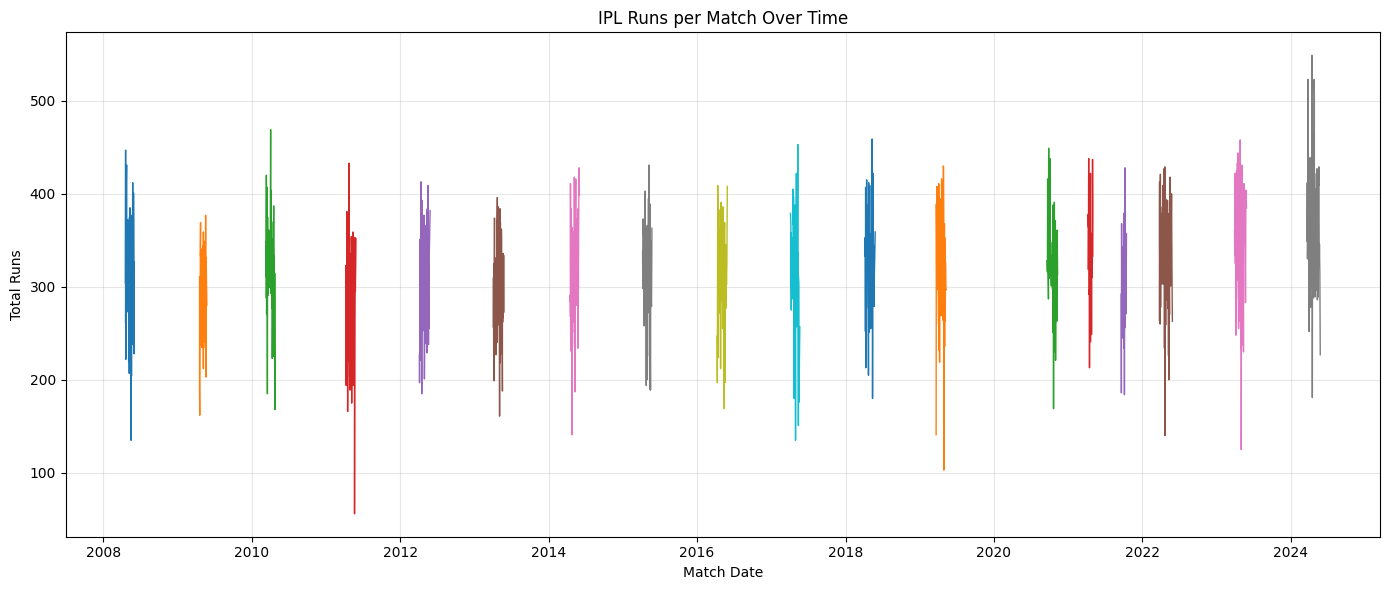

In [24]:
# Creates the Runs per Match time-series chart without connecting long date gaps.

plt.figure(figsize=(14, 6))

for season, season_data in runs_per_match.groupby("season"):
    season_data = season_data.sort_values("date").copy()

    # Starts a new segment whenever the gap between matches is more than 30 days.
    season_data["segment"] = (
        season_data["date"].diff().dt.days.gt(30).cumsum()
    )

    for _, segment_data in season_data.groupby("segment"):
        plt.plot(
            segment_data["date"],
            segment_data["total_runs"],
            linewidth=1
        )

plt.title("IPL Runs per Match Over Time")
plt.xlabel("Match Date")
plt.ylabel("Total Runs")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "images/runs_per_match.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# Calculates the total runs scored by each batter.

top_run_scorers = (
    deliveries_clean
    .groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_run_scorers

,batter,batsman_runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


In [26]:
# Renames the columns for better readability.

top_run_scorers.columns = ["Player", "Runs"]

top_run_scorers

,Player,Runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


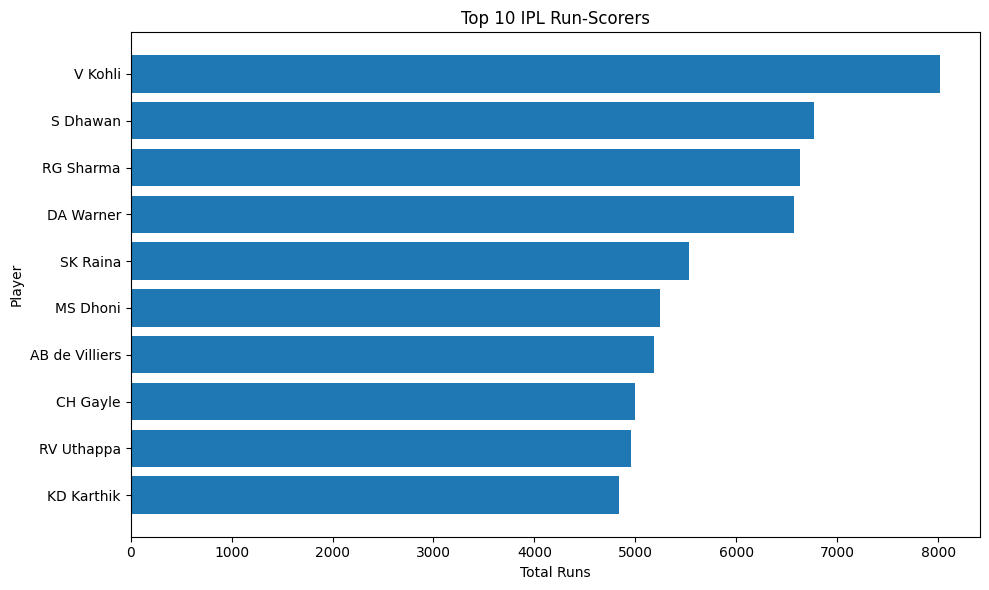

In [27]:
# Creates the Top 10 Run-Scorers chart.

plt.figure(figsize=(10, 6))

plt.barh(
    top_run_scorers["Player"],
    top_run_scorers["Runs"]
)

plt.title("Top 10 IPL Run-Scorers")
plt.xlabel("Total Runs")
plt.ylabel("Player")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "images/top_10_run_scorers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# Displays all unique dismissal types in the dataset.

dismissal_types = deliveries_clean["dismissal_kind"].dropna().unique()

dismissal_types

<StringArray>
[               'caught',                'bowled',               'run out',
                   'lbw',          'retired hurt',               'stumped',
     'caught and bowled',            'hit wicket', 'obstructing the field',
           'retired out']
Length: 10, dtype: str

In [29]:
# Defines dismissal types that are credited to the bowler.

bowler_wicket_types = [
    "caught",
    "bowled",
    "lbw",
    "stumped",
    "caught and bowled",
    "hit wicket"
]

In [30]:
# Filters deliveries to include only wickets credited to bowlers.

bowler_wickets = deliveries_clean[
    deliveries_clean["dismissal_kind"].isin(bowler_wicket_types)
]

bowler_wickets.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
33,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,5,2,SC Ganguly,Z Khan,BB McCullum,0,0,0,NaN,1,SC Ganguly,caught,JH Kallis
74,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,12,1,RT Ponting,JH Kallis,BB McCullum,0,0,0,NaN,1,RT Ponting,caught,P Kumar
106,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,17,1,DJ Hussey,AA Noffke,BB McCullum,0,0,0,NaN,1,DJ Hussey,caught,CL White
131,335982,2,Royal Challengers Bengaluru,Kolkata Knight Riders,1,1,R Dravid,I Sharma,W Jaffer,0,0,0,NaN,1,R Dravid,bowled,NaN
138,335982,2,Royal Challengers Bengaluru,Kolkata Knight Riders,2,2,V Kohli,AB Dinda,W Jaffer,0,0,0,NaN,1,V Kohli,bowled,NaN


In [31]:
# Calculates the Top 10 wicket-takers.

top_wicket_takers = (
    bowler_wickets
    .groupby("bowler")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="Wickets")
)

top_wicket_takers

,bowler,Wickets
0,YS Chahal,205
1,PP Chawla,192
2,DJ Bravo,183
3,B Kumar,181
4,R Ashwin,180
5,SP Narine,180
6,A Mishra,174
7,SL Malinga,170
8,JJ Bumrah,168
9,RA Jadeja,160


In [32]:
# Renames the bowler column for better readability.

top_wicket_takers = top_wicket_takers.rename(
    columns={"bowler": "Player"}
)

top_wicket_takers

,Player,Wickets
0,YS Chahal,205
1,PP Chawla,192
2,DJ Bravo,183
3,B Kumar,181
4,R Ashwin,180
5,SP Narine,180
6,A Mishra,174
7,SL Malinga,170
8,JJ Bumrah,168
9,RA Jadeja,160


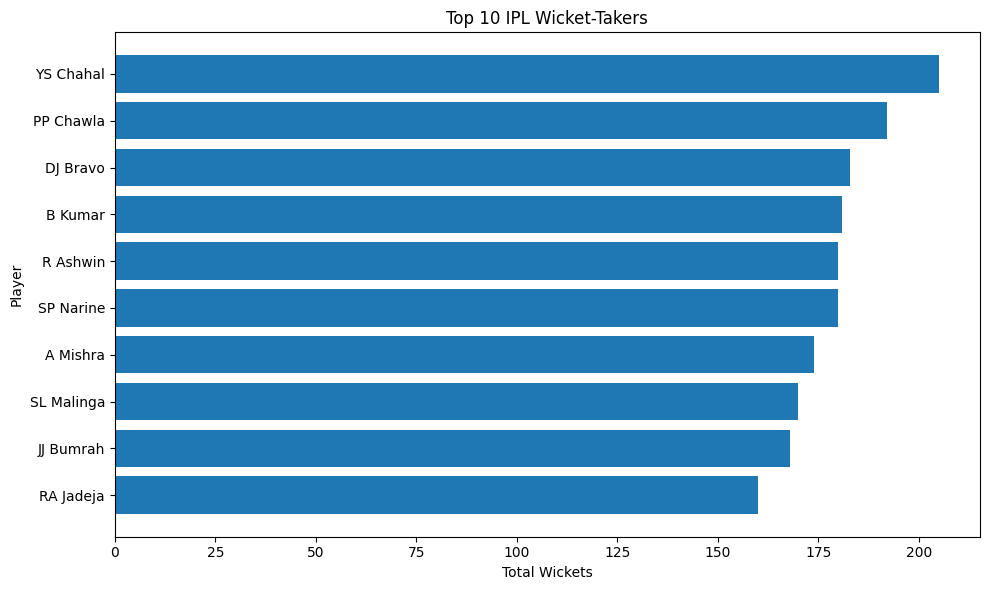

In [33]:
# Creates the Top 10 Wicket-Takers chart.

plt.figure(figsize=(10, 6))

plt.barh(
    top_wicket_takers["Player"],
    top_wicket_takers["Wickets"]
)

plt.title("Top 10 IPL Wicket-Takers")
plt.xlabel("Total Wickets")
plt.ylabel("Player")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "images/top_10_wicket_takers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
# Counts the total number of matches played by each team.

matches_played = pd.concat([
    matches_clean["team1"],
    matches_clean["team2"]
]).value_counts().reset_index()

matches_played.columns = ["Team", "Matches Played"]

matches_played

,Team,Matches Played
0,Mumbai Indians,261
1,Royal Challengers Bengaluru,255
2,Delhi Capitals,252
3,Kolkata Knight Riders,251
4,Punjab Kings,246
5,Chennai Super Kings,238
6,Rajasthan Royals,221
7,Sunrisers Hyderabad,182
8,Deccan Chargers,75
9,Pune Warriors,46


In [35]:
# Counts the total number of wins for each team.

team_wins = (
    matches_clean["winner"]
    .value_counts()
    .reset_index()
)

team_wins.columns = ["Team", "Wins"]

team_wins

,Team,Wins
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bengaluru,123
4,Delhi Capitals,115
5,Rajasthan Royals,112
6,Punjab Kings,112
7,Sunrisers Hyderabad,88
8,Deccan Chargers,29
9,Gujarat Titans,28


In [36]:
# Combines matches played and wins for each team.

team_win_percentage = matches_played.merge(
    team_wins,
    on="Team",
    how="left"
)

team_win_percentage["Wins"] = (
    team_win_percentage["Wins"]
    .fillna(0)
    .astype(int)
)

team_win_percentage

,Team,Matches Played,Wins
0,Mumbai Indians,261,144
1,Royal Challengers Bengaluru,255,123
2,Delhi Capitals,252,115
3,Kolkata Knight Riders,251,131
4,Punjab Kings,246,112
5,Chennai Super Kings,238,138
6,Rajasthan Royals,221,112
7,Sunrisers Hyderabad,182,88
8,Deccan Chargers,75,29
9,Pune Warriors,46,12


In [37]:
# Calculates the win percentage for each team.

team_win_percentage["Win Percentage"] = (
    team_win_percentage["Wins"]
    / team_win_percentage["Matches Played"]
    * 100
).round(2)

team_win_percentage = team_win_percentage.sort_values(
    "Win Percentage",
    ascending=False
).reset_index(drop=True)

team_win_percentage

,Team,Matches Played,Wins,Win Percentage
0,Gujarat Titans,45,28,62.22
1,Chennai Super Kings,238,138,57.98
2,Mumbai Indians,261,144,55.17
3,Lucknow Super Giants,44,24,54.55
4,Kolkata Knight Riders,251,131,52.19
5,Rajasthan Royals,221,112,50.68
6,Rising Pune Supergiant,30,15,50.00
7,Sunrisers Hyderabad,182,88,48.35
8,Royal Challengers Bengaluru,255,123,48.24
9,Delhi Capitals,252,115,45.63


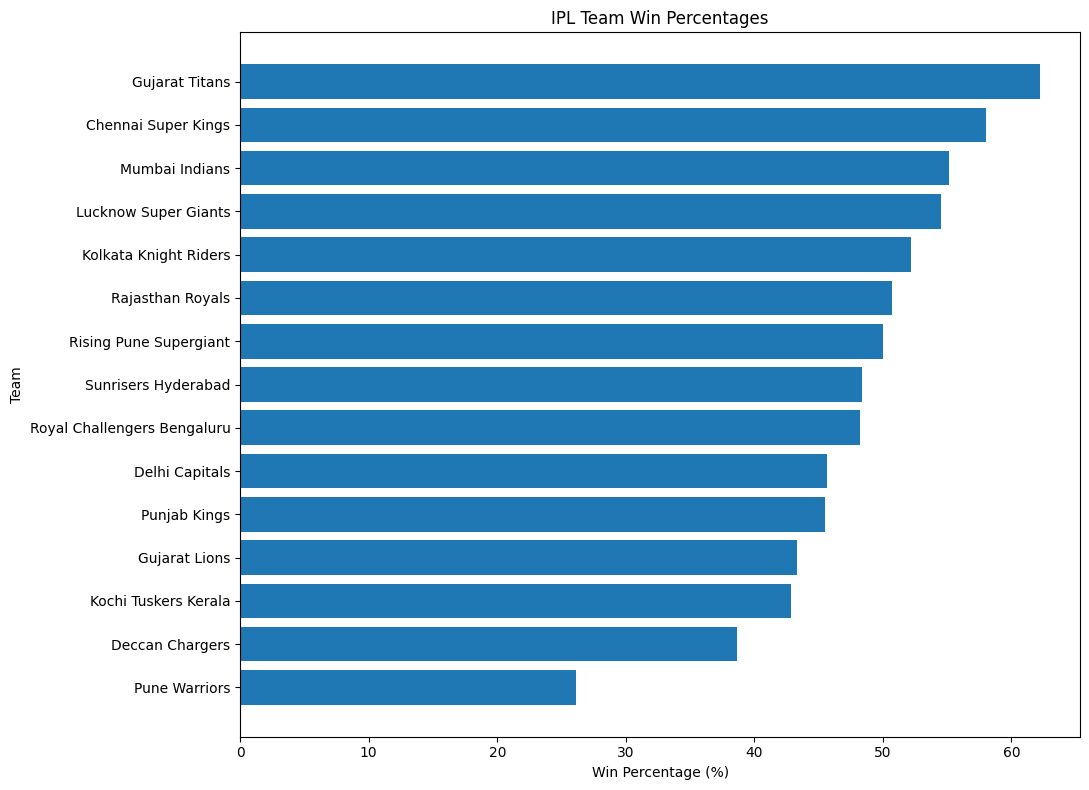

In [38]:
# Creates the Team Win Percentage chart.

plt.figure(figsize=(11, 8))

plt.barh(
    team_win_percentage["Team"],
    team_win_percentage["Win Percentage"]
)

plt.title("IPL Team Win Percentages")
plt.xlabel("Win Percentage (%)")
plt.ylabel("Team")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "images/team_win_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# Imports tools for creating interactive dashboard filters.

import ipywidgets as widgets
from IPython.display import display

In [40]:
# Creates the Season and Team dropdown filters.

season_options = ["All Seasons"] + sorted(
    matches_clean["season"].dropna().unique().tolist()
)

team_options = ["All Teams"] + sorted(
    set(matches_clean["team1"].dropna()) |
    set(matches_clean["team2"].dropna())
)

season_dropdown = widgets.Dropdown(
    options=season_options,
    value="All Seasons",
    description="Season:"
)

team_dropdown = widgets.Dropdown(
    options=team_options,
    value="All Teams",
    description="Team:"
)

display(season_dropdown, team_dropdown)

Dropdown(description='Season:', options=('All Seasons', '2007/08', '2009', '2009/10', '2011', '2012', '2013', …

Dropdown(description='Team:', options=('All Teams', 'Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals'…

In [41]:
# Creates the complete interactive IPL statistics dashboard.

def update_dashboard(season, team):

    # -----------------------------
    # FILTER MATCH DATA
    # -----------------------------
    filtered_matches = matches_clean.copy()

    if season != "All Seasons":
        filtered_matches = filtered_matches[
            filtered_matches["season"] == season
        ]

    if team != "All Teams":
        filtered_matches = filtered_matches[
            (filtered_matches["team1"] == team) |
            (filtered_matches["team2"] == team)
        ]

    # Gets the match IDs based on the selected filters.
    selected_match_ids = filtered_matches["id"].tolist()

    # Gets all deliveries from the selected matches.
    filtered_deliveries = deliveries_clean[
        deliveries_clean["match_id"].isin(selected_match_ids)
    ]

    # Creates team-specific batting and bowling data.
    if team != "All Teams":
        batting_deliveries = filtered_deliveries[
            filtered_deliveries["batting_team"] == team
        ]

        bowling_deliveries = filtered_deliveries[
            filtered_deliveries["bowling_team"] == team
        ]

    else:
        batting_deliveries = filtered_deliveries
        bowling_deliveries = filtered_deliveries


    # Creates the 2x2 dashboard layout.
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))


    # ==========================================
    # 1. RUNS PER MATCH
    # ==========================================

    filtered_runs = (
        filtered_deliveries
        .groupby("match_id")["total_runs"]
        .sum()
        .reset_index()
    )

    filtered_runs = filtered_runs.merge(
        filtered_matches[["id", "date", "season"]],
        left_on="match_id",
        right_on="id",
        how="left"
    )

    filtered_runs = filtered_runs.sort_values("date")

    for current_season, season_data in filtered_runs.groupby("season"):

        season_data = season_data.sort_values("date").copy()

        # Separates long breaks between matches.
        season_data["segment"] = (
            season_data["date"]
            .diff()
            .dt.days
            .gt(30)
            .cumsum()
        )

        for _, segment_data in season_data.groupby("segment"):
            axes[0, 0].plot(
                segment_data["date"],
                segment_data["total_runs"],
                linewidth=1
            )

    axes[0, 0].set_title("Runs per Match Over Time")
    axes[0, 0].set_xlabel("Match Date")
    axes[0, 0].set_ylabel("Total Runs")
    axes[0, 0].grid(alpha=0.3)


    # ==========================================
    # 2. TOP 10 RUN-SCORERS
    # ==========================================

    filtered_scorers = (
        batting_deliveries
        .groupby("batter")["batsman_runs"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .sort_values()
    )

    axes[0, 1].barh(
        filtered_scorers.index,
        filtered_scorers.values
    )

    axes[0, 1].set_title("Top 10 Run-Scorers")
    axes[0, 1].set_xlabel("Total Runs")
    axes[0, 1].set_ylabel("Player")


    # ==========================================
    # 3. TOP 10 WICKET-TAKERS
    # ==========================================

    filtered_wickets = bowling_deliveries[
        bowling_deliveries["dismissal_kind"].isin(
            bowler_wicket_types
        )
    ]

    filtered_wicket_takers = (
        filtered_wickets
        .groupby("bowler")
        .size()
        .sort_values(ascending=False)
        .head(10)
        .sort_values()
    )

    axes[1, 0].barh(
        filtered_wicket_takers.index,
        filtered_wicket_takers.values
    )

    axes[1, 0].set_title("Top 10 Wicket-Takers")
    axes[1, 0].set_xlabel("Total Wickets")
    axes[1, 0].set_ylabel("Player")


    # ==========================================
    # 4. TEAM WIN PERCENTAGE
    # ==========================================

    if team == "All Teams":

        filtered_matches_played = pd.concat([
            filtered_matches["team1"],
            filtered_matches["team2"]
        ]).value_counts()

        filtered_team_wins = (
            filtered_matches["winner"]
            .value_counts()
        )

        filtered_win_percentage = (
            filtered_team_wins
            .reindex(
                filtered_matches_played.index,
                fill_value=0
            )
            / filtered_matches_played
            * 100
        ).sort_values()

        axes[1, 1].barh(
            filtered_win_percentage.index,
            filtered_win_percentage.values
        )

        axes[1, 1].set_xlim(0, 100)

    else:

        matches_count = len(filtered_matches)

        wins_count = (
            filtered_matches["winner"] == team
        ).sum()

        win_percentage = (
            wins_count / matches_count * 100
            if matches_count > 0
            else 0
        )

        axes[1, 1].barh(
            [team],
            [win_percentage]
        )

        # Uses a fixed percentage scale.
        axes[1, 1].set_xlim(0, 100)

        # Displays the exact win percentage beside the bar.
        axes[1, 1].text(
            win_percentage + 1,
            0,
            f"{win_percentage:.2f}%",
            va="center"
        )

    axes[1, 1].set_title("Team Win Percentage")
    axes[1, 1].set_xlabel("Win Percentage (%)")
    axes[1, 1].set_ylabel("Team")


    # ==========================================
    # DASHBOARD TITLE
    # ==========================================

    fig.suptitle(
        f"IPL Statistics Dashboard | Season: {season} | Team: {team}",
        fontsize=16
    )

    plt.tight_layout()

    plt.show()

In [42]:
# Connects the dropdown filters to the dashboard.

dashboard_output = widgets.interactive_output(
    update_dashboard,
    {
        "season": season_dropdown,
        "team": team_dropdown
    }
)

dashboard_filters = widgets.HBox([
    season_dropdown,
    team_dropdown
])

display(dashboard_filters, dashboard_output)

Output()

## Brief Insights

- Virat Kohli is the leading run-scorer in the dataset with 8,014 runs, followed by Shikhar Dhawan and Rohit Sharma.
- Yuzvendra Chahal leads the wicket-taking rankings with 205 wickets, followed by Piyush Chawla and Dwayne Bravo.
- Gujarat Titans have the highest overall win percentage in the dataset at 62.22%, while Chennai Super Kings and Mumbai Indians also show strong win rates.
- Total runs per match vary considerably across IPL seasons, with several matches recording more than 400 combined runs and some recent matches exceeding 500 runs.
- The Season and Team filters allow the dashboard to show more specific performance patterns for individual teams and seasons.